## Load data from interferometer
Here is the script about how to load the data from the interferometer. For the three files:

| File            | What it is                                 | How to use it                                                                                                                                                                                               |
| --------------- | ------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `CM2_4mm-3.asc` | Text export with metadata + height map     | Best file to load first. It contains `X Size = 1280`, `Y Size = 960`, height unit `nm`, pixel spacing `0.176875`, and then the 2-D surface data. Invalid pixels are written as `Bad`.                       |
| `CM2_4mm-3.txt` | Plain matrix export of the same height map | Same numerical data as `.asc`, but without useful metadata. Invalid pixels are written as `inf`.                                                                                                            |
| `CM2_4mm-3.hll` | Binary/proprietary container               | Contains the raw/binary measurement data. In this file it starts with `HOOL INTERNATIONAL LLC - 1.0.0.5` and contains three `float32` maps after a 624-byte header. Use only if you need raw/internal maps. |


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import os
from PIL import Image


In [2]:
def load_asc(path):
    path = Path(path)
    lines = path.read_text(errors="replace").splitlines()

    # Header ends at the first blank line
    blank = next(i for i, line in enumerate(lines) if line.strip() == "")

    meta = {}
    for line in lines[:blank]:
        parts = line.split("\t")
        if len(parts) >= 2:
            key = parts[0].strip()
            value = parts[1].strip()
            unit = parts[2].strip() if len(parts) >= 3 else ""
            try:
                value = float(value)
                if value.is_integer():
                    value = int(value)
            except Exception:
                pass
            meta[key] = value
            if unit:
                meta[key + " Unit"] = unit

    z = np.genfromtxt(
        path,
        delimiter="\t",
        skip_header=blank + 1,
        dtype=float,
        invalid_raise=False,
        autostrip=True,
    )

    # Remove trailing empty column caused by final tab
    if z.ndim == 2 and np.all(~np.isfinite(z[:, -1])):
        z = z[:, :-1]

    # "Bad" becomes NaN; also remove inf
    z[~np.isfinite(z)] = np.nan

    return z, meta


def load_txt(path):
    z = np.genfromtxt(
        path,
        delimiter="\t",
        skip_header=1,
        dtype=float,
        invalid_raise=False,
    )

    if z.ndim == 2 and np.all(~np.isfinite(z[:, -1])):
        z = z[:, :-1]

    z[~np.isfinite(z)] = np.nan
    return z


def plot_map(z, title="Height map", unit="nm"):
    plt.figure(figsize=(8, 5.5))
    im = plt.imshow(z, origin="upper", aspect="equal")
    plt.title(title)
    plt.xlabel("x pixel")
    plt.ylabel("y pixel")
    cbar = plt.colorbar(im)
    cbar.set_label(unit)
    plt.tight_layout()
    plt.show()

def load_hll_this_format(path, nx=1280, ny=960, offset=624):
    """
    Experimental reader for this uploaded .hll file.

    The file contains three little-endian float32 maps after byte 624.
    Very large values, around 3.4e38, are invalid pixels.
    """
    raw = np.fromfile(path, dtype="<f4", offset=offset)

    pixels = nx * ny
    n_maps = raw.size // pixels

    raw = raw[: n_maps * pixels]
    maps = raw.reshape(n_maps, ny, nx).astype(float)

    maps[maps > 1e30] = np.nan

    return [maps[i] for i in range(n_maps)]

Metadata:
X Size = 1280
X Size Unit = pix
Y Size = 960
Y Size Unit = pix
Wavelenth = 532
Wavelenth Unit = mm
Heigh Unit = nm
xPixSpace = 0.176875
xPixSpace Unit = mm
Shape: (960, 1280)
Finite pixels: 10420
Min: -44.419612706
Mean: -5.221903070054135e-07
Max: 79.419138312
PV: 123.83875101800001
RMS: 33.05878079279481


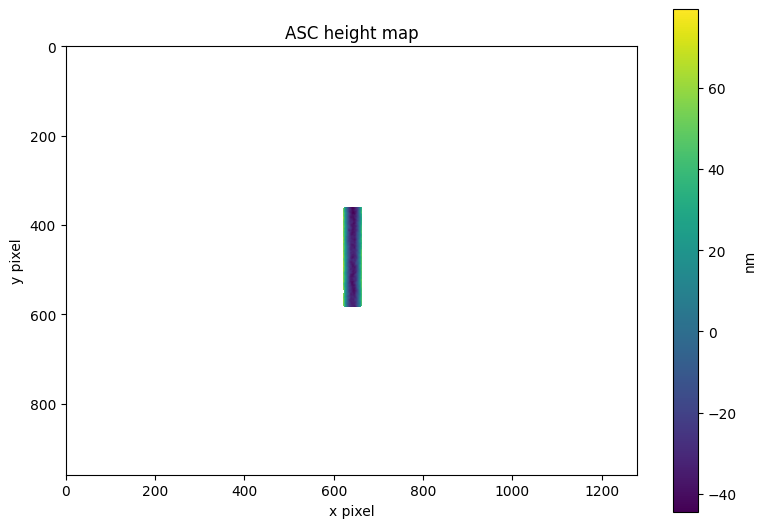

In [3]:
folder = 'D:\\exp_data\\干涉仪数据-2026\\CM2测量原始数据\\CM2测量原始数据\\[WS]M260617-move4mm\\'
file_txt = folder + '\\temp\\CM2_4mm-3.txt'
file_asc = folder +'CM2_4mm-3.asc'
file_hll = folder + 'CM2_4mm-3.hll'

z_asc, meta = load_asc(file_asc)

print("Metadata:")
for k, v in meta.items():
    print(k, "=", v)

print("Shape:", z_asc.shape)
print("Finite pixels:", np.isfinite(z_asc).sum())
print("Min:", np.nanmin(z_asc))
print("Mean:", np.nanmean(z_asc))
print("Max:", np.nanmax(z_asc))
print("PV:", np.nanmax(z_asc) - np.nanmin(z_asc))
print("RMS:", np.sqrt(np.nanmean((z_asc - np.nanmean(z_asc)) ** 2)))


plot_map(z_asc, "ASC height map", unit=meta.get("Heigh Unit", "nm"))


Map 0
  shape: (960, 1280)
  finite: 10420
  min: -0.05188293382525444
  mean: 0.031612577401009624
  max: 0.18089666962623596


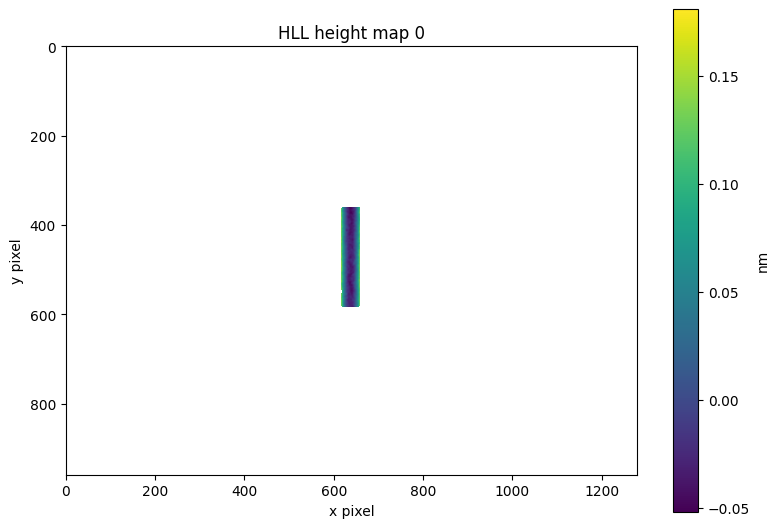

Map 1
  shape: (960, 1280)
  finite: 10425
  min: -0.08349551260471344
  mean: -9.810824474270682e-10
  max: 0.14928409457206726


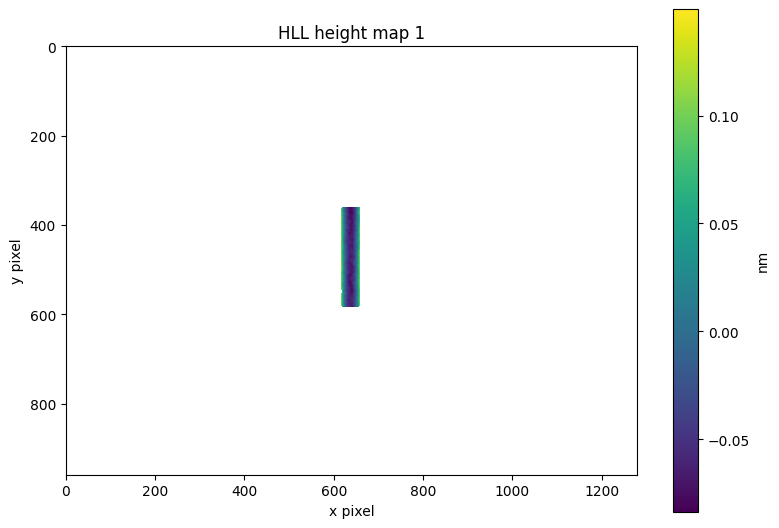

Map 2
  shape: (960, 1280)
  finite: 1228800
  min: -0.0
  mean: 3.732108928903058e-11
  max: 4.3194915633648634e-05


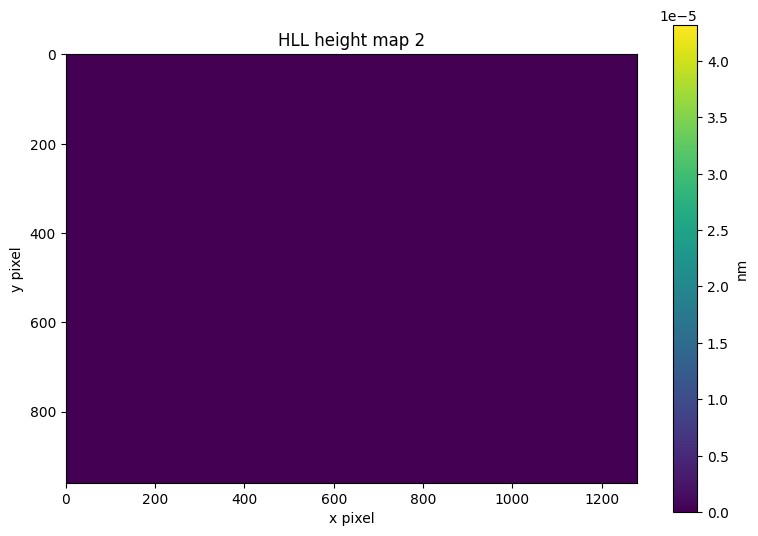

In [5]:

maps = load_hll_this_format(file_hll)

for i, m in enumerate(maps):
    print("Map", i)
    print("  shape:", m.shape)
    print("  finite:", np.isfinite(m).sum())
    print("  min:", np.nanmin(m))
    print("  mean:", np.nanmean(m))
    print("  max:", np.nanmax(m))
    plot_map(m, f"HLL height map {i}", unit="nm")

### save the stitching data into one image to check

Found 69 ASC files in D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\M260617-move4mm\
Metadata:
X Size = 1280
X Size Unit = pix
Y Size = 960
Y Size Unit = pix
Wavelenth = 532
Wavelenth Unit = mm
Heigh Unit = nm
xPixSpace = 0.176875
xPixSpace Unit = mm
Shape: (960, 1280)
Finite pixels: 10423
Min: -50.724307865
Mean: -5.773667851497445e-07
Max: 90.870832324
PV: 141.595140189
RMS: 33.99227402682523


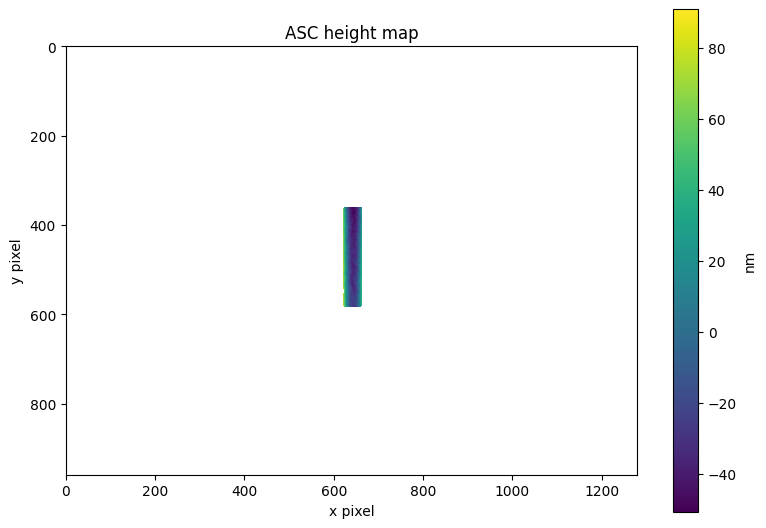

In [26]:
folder = 'D:\\exp_data\\干涉仪数据-2026\\CM2测量原始数据\\CM2测量原始数据\\M260617-move4mm\\'
file_asc_list = glob(os.path.join(folder, '*.asc'))

print(f"Found {len(file_asc_list)} ASC files in {folder}")
data = []
for file_asc in file_asc_list:
    z_asc, meta = load_asc(file_asc)
    data.append(z_asc)

print("Metadata:")
for k, v in meta.items():
    print(k, "=", v)

print("Shape:", z_asc.shape)
print("Finite pixels:", np.isfinite(z_asc).sum())
print("Min:", np.nanmin(z_asc))
print("Mean:", np.nanmean(z_asc))
print("Max:", np.nanmax(z_asc))
print("PV:", np.nanmax(z_asc) - np.nanmin(z_asc))
print("RMS:", np.sqrt(np.nanmean((z_asc - np.nanmean(z_asc)) ** 2)))

plot_map(z_asc, "ASC height map", unit=meta.get("Heigh Unit", "nm"))


In [27]:
print(f"Loaded {len(data)} ASC files from {folder}")

Loaded 69 ASC files from D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\M260617-move4mm\


In [29]:
# use PIL to save image stack as tiff image
# Image.fromarray(np.array([m for m, _ in data])).save(folder + 'CM2_4mm-3_stack.tiff')
frames = [Image.fromarray(np.asarray(m, dtype=np.float32), mode="F") for m in data]
print(f"Saving {len(frames)} frames to {folder + 'CM2_4mm-3_stack.tiff'}")
frames[0].save(
    folder + "CM2_4mm-3_stack.tiff",
    save_all=True,
    append_images=frames[1:]
)


Saving 69 frames to D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\M260617-move4mm\CM2_4mm-3_stack.tiff


Using file: D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\卧式系统标定文件\[REF]JSP-260410-FS-C3.xlsx
Sheet: reference
Shape: (960, 1280)
Finite pixels: 1228800
Min: -4.060190664734495
Mean: 57242.008119214486
Max: 65535.0
PV: 65539.06019066474
RMS: 21787.78110269438


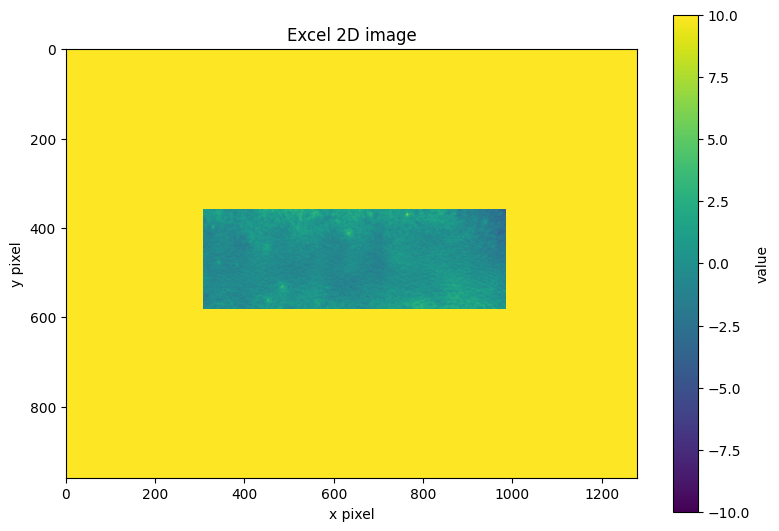

In [31]:
from openpyxl import load_workbook

folder = Path(r"D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\卧式系统标定文件")

# Pick first Excel file in this folder
excel_candidates = []
for ext in ("*.xlsx", "*.xlsm", "*.xltx", "*.xltm"):
    excel_candidates.extend(sorted(folder.glob(ext)))

if not excel_candidates:
    raise FileNotFoundError(f"No Excel file found in: {folder}")

excel_path = excel_candidates[0]
print("Using file:", excel_path)

def to_float_or_nan(v):
    if v is None:
        return np.nan
    if isinstance(v, (int, float)):
        return float(v)
    if isinstance(v, str):
        s = v.strip()
        if s == "" or s.lower() in {"bad", "nan", "inf", "+inf", "-inf"}:
            return np.nan
        try:
            return float(s)
        except ValueError:
            return np.nan
    return np.nan

def trim_nan_border(arr):
    # Remove all-NaN outer rows/cols
    if arr.size == 0:
        return arr
    valid = np.isfinite(arr)
    if not valid.any():
        return arr
    row_keep = valid.any(axis=1)
    col_keep = valid.any(axis=0)
    return arr[row_keep][:, col_keep]

def load_excel_2d(path, sheet_name=None, min_row=1, min_col=1, max_row=None, max_col=None):
    wb = load_workbook(path, data_only=True, read_only=True)
    ws = wb[sheet_name] if sheet_name else wb[wb.sheetnames[0]]

    rows = []
    for r in ws.iter_rows(
        min_row=min_row, max_row=max_row,
        min_col=min_col, max_col=max_col,
        values_only=True
    ):
        rows.append([to_float_or_nan(v) for v in r])

    arr = np.asarray(rows, dtype=np.float64)
    arr = trim_nan_border(arr)
    return arr, ws.title

z, sheet = load_excel_2d(excel_path, sheet_name=None)
z[~np.isfinite(z)] = np.nan

print("Sheet:", sheet)
print("Shape:", z.shape)
print("Finite pixels:", np.isfinite(z).sum())
print("Min:", np.nanmin(z))
print("Mean:", np.nanmean(z))
print("Max:", np.nanmax(z))
print("PV:", np.nanmax(z) - np.nanmin(z))
print("RMS:", np.sqrt(np.nanmean((z - np.nanmean(z)) ** 2)))



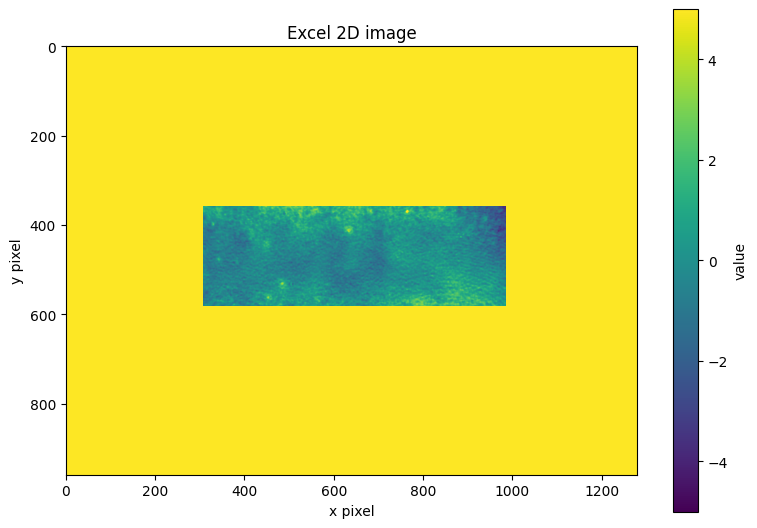

In [34]:
plt.figure(figsize=(8, 5.5))
im = plt.imshow(z, origin="upper", aspect="equal")
plt.title("Excel 2D image")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.clim([-5,5])
plt.colorbar(im, label="value")
plt.tight_layout()
plt.show()

In [35]:
np.save(folder / "CM2_4mm-3_excel.npy", z)